In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from itertools import product
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score, precision_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
scaler = StandardScaler()
sns.set_style("whitegrid")

# Sanity check

In [2]:
glass_identification = fetch_ucirepo(id=42)
X_glass = glass_identification.data.features
y_glass = glass_identification.data.targets
df_glass = pd.concat([X_glass, y_glass], axis=1)
df_glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [3]:
X = df_glass.drop(columns=['Type_of_glass'])
y = df_glass['Type_of_glass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
rf = RandomForestClassifier()
ada = AdaBoostClassifier(algorithm='SAMME')
hist = HistGradientBoostingClassifier()

rf = rf.fit(X_train, y_train)
ada = ada.fit(X_train, y_train)
catboost = hist.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
ada_pred = ada.predict(X_test)
hist_pred = hist.predict(X_test)

In [5]:
print("Random Forest Classifier")
print(classification_report(y_test, rf_pred))
print("AdaBoost Classifier")
print(classification_report(y_test, ada_pred))

Random Forest Classifier
              precision    recall  f1-score   support

           1       0.58      0.92      0.71        12
           2       0.77      0.48      0.59        21
           3       1.00      1.00      1.00         1
           5       0.50      0.50      0.50         4
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         3

    accuracy                           0.67        43
   macro avg       0.75      0.82      0.77        43
weighted avg       0.71      0.67      0.66        43

AdaBoost Classifier
              precision    recall  f1-score   support

           1       0.59      0.83      0.69        12
           2       0.67      0.57      0.62        21
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00         2
           7       1.00      1.00      1.00         3

    accuracy                    

c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [6]:
print("CatBoost Classifier")
print(classification_report(y_test, hist_pred))

CatBoost Classifier
              precision    recall  f1-score   support

           1       0.75      0.75      0.75        12
           2       0.83      0.71      0.77        21
           3       0.25      1.00      0.40         1
           5       1.00      0.75      0.86         4
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         3

    accuracy                           0.77        43
   macro avg       0.75      0.87      0.76        43
weighted avg       0.82      0.77      0.78        43



# COMPAS - podstawowe informacje

System COMPAS to oprogramowanie do zarządzania sprawami karnymi i wspierania decyzji, opracowane przez firmę Equivant, służące amerykańskim sądom do oceny prawdopodobieństwa recydywy u oskarżonych. Wersja zbioru danych została udostępniona przez ProPublica. Zawiera identyfikatory i metdane, dane deomgraficzne, personalia, historie kryminalna i przestępstwa popełnione w młodości, szczegóły związane z oceną COMPAS, dane czasowe i więzienne, szczegóły zarzutów i recydywy, wskaźniki i opis recydywy brutalnej, zmienne etykietujące.

In [7]:
raw_data = pd.read_csv('compas-scores-two-years.csv')
raw_data

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,...,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,...,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,Male,1958-10-01,57,Greater than 45,Other,...,1,Low,2014-01-14,2014-01-13,2014-01-14,0,0,808,0,0
7212,11000,farrah jean,farrah,jean,2014-03-09,Female,1982-11-17,33,25 - 45,African-American,...,2,Low,2014-03-09,2014-03-08,2014-03-09,3,0,754,0,0


In [8]:
print("raw_data shape:", raw_data.shape)

raw_data shape: (7214, 53)


In [10]:
age_cat_grouped = raw_data.groupby('age_cat')['two_year_recid'].sum().reset_index()
print("Grouped age_cat by priors_count:")
print(age_cat_grouped)

Grouped age_cat by priors_count:
           age_cat  two_year_recid
0          25 - 45            1889
1  Greater than 45             498
2     Less than 25             864


In [9]:
age_cat_grouped = raw_data.groupby('age_cat')['priors_count'].mean().reset_index()
print("Grouped age_cat by priors_count:")
print(age_cat_grouped)

Grouped age_cat by priors_count:
           age_cat  priors_count
0          25 - 45      3.936481
1  Greater than 45      4.221447
2     Less than 25      1.453237


In [11]:
df = raw_data.drop(columns=['id','name', 'first', 'last','dob','compas_screening_date', 'screening_date','c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date','r_case_number', 'r_charge_degree', 'r_days_from_arrest',
    'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out','vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc','v_screening_date', 'in_custody', 'out_custody','decile_score.1','v_decile_score','v_score_text', 'type_of_assessment','v_type_of_assessment', 'priors_count.1','violent_recid','start', 'end', 'event', 'is_recid', 'is_violent_recid', 'age_cat',
    'decile_score', 'score_text'])

In [12]:
df = df.dropna()
df

,sex,age,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,c_charge_degree,c_charge_desc,two_year_recid
0,Male,69,Other,0,0,0,0,-1.0,1.0,F,Aggravated Assault w/Firearm,0
1,Male,34,African-American,0,0,0,0,-1.0,1.0,F,Felony Battery w/Prior Convict,1
2,Male,24,African-American,0,0,1,4,-1.0,1.0,F,Possession of Cocaine,1
5,Male,44,Other,0,0,0,0,0.0,0.0,M,Battery,0
6,Male,41,Caucasian,0,0,0,14,-1.0,1.0,F,Possession Burglary Tools,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7209,Male,23,African-American,0,0,0,0,-1.0,1.0,F,Deliver Cannabis,0
7210,Male,23,African-American,0,0,0,0,-1.0,1.0,F,Leaving the Scene of Accident,0
7211,Male,57,Other,0,0,0,0,-1.0,1.0,F,Aggravated Battery / Pregnant,0
7212,Female,33,African-American,0,0,0,3,-1.0,1.0,M,Battery on Law Enforc Officer,0


In [12]:
print("Two_year_recid by sex") 
print(df.groupby('sex')['two_year_recid'].value_counts(normalize=True)*100)

Two_year_recid by sex
sex     two_year_recid
Female  0                 63.273002
        1                 36.726998
Male    0                 51.417295
        1                 48.582705
Name: proportion, dtype: float64


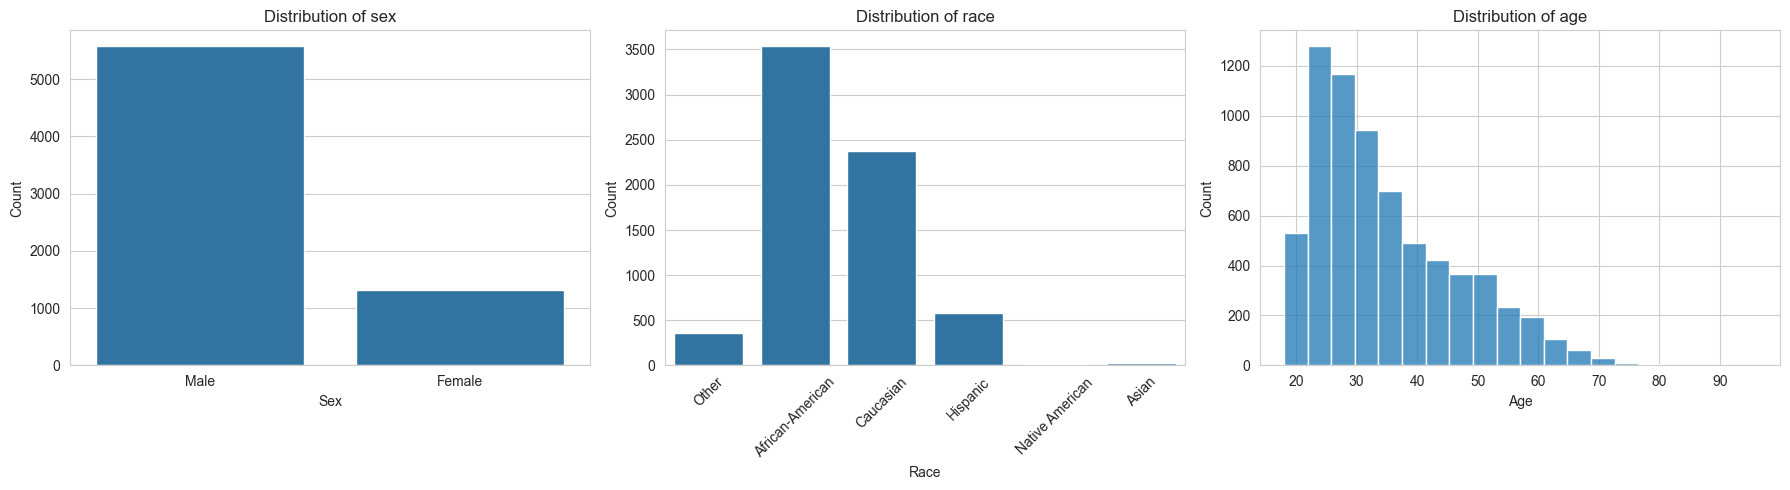

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x='sex', data=df, ax=ax[0])
ax[0].set_title('Distribution of sex')
ax[0].set_ylabel('Count')
ax[0].set_xlabel('Sex')
sns.countplot(x='race', data=df, ax=ax[1])
ax[1].set_title('Distribution of race')
ax[1].set_ylabel('Count')
ax[1].set_xlabel('Race')
ax[1].tick_params(axis='x', rotation=45)
sns.histplot(df['age'], kde=False, ax=ax[2], bins=20)
ax[2].set_title('Distribution of age')
ax[2].set_xlabel('Age')
ax[2].set_ylabel('Count')
plt.tight_layout()

In [14]:
two_year_recid = df['two_year_recid'].value_counts(normalize=True) * 100
two_year_recid

two_year_recid
0    53.695652
1    46.304348
Name: proportion, dtype: float64

In [15]:
X_compas = df.drop(columns=['two_year_recid'])
y_compas = df['two_year_recid']

## Przygotowanie zbioru

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X_compas, y_compas, test_size=0.2, shuffle=True, stratify=y_compas)
cat_cols = ["sex", "race", "c_charge_degree", "c_charge_desc"]
num_cols = [col for col in X_train.columns if col not in cat_cols]

## Hiperparametry zespołów klasyfikatorów

**Random Forest**
- metoda zespołowa (ensemble), która łączy wiele niezależnych drzew decyzyjnych, aby poprawić stabilność i dokładność predykcji,
- bootstrap - dla każdego drzewa losujemy z oryginalnego zbioru treningowego podzbiór o tej samej wielkości, ale ze zwracaniem – czyli pojedynczy przykład może się powtórzyć, a część przykładów w ogóle nie trafić do danego drzewa.
- losowy podzbiór cech - przy każdym dzieleniu w drzewie wybieramy najlepszy podział tylko spośród losowo wybranej podgrupy cech, co zwiększa różnorodność drzew
- agregacja - w regresji uśredniamy prognozy wszystkich drzew, w klasyfikacji stosujemy głosowanie większościowe

**AdaBoost**
- metoda zespołowa, która tworzy sekwencję słabych klasyfikatorów, gdzie każdy kolejny klasyfikator uczy się na błędach poprzedniego
- każdemu przykładowi treningowemu przypisujemy początkową wagę (jednakową dla wszystkich)
- przy każdym kroku uczymy nowy klasyfikator, minimalizując błąd ważony (większą wagę mają te punkty, które poprzednie klasyfikatory sklasyfikowały niewłaściwie)
- po wytrenowaniu klasyfikatora zwiększamy wagę przykładów błędnie sklasyfikowanych, zmniejszamy wagę tych sklasyfikowanych poprawnie
- każdy słaby klasyfikator otrzymuje wagę proporcjonalną do swojej dokładności, a w predykcji sumujemy ich głosy ważone i dokonujemy klasyfikacji na podstawie znaku tej sumy

**Histogram-based Gradient Boosting**
- to wariant algorytmów gradient boosting opartych na drzewach decyzyjnych, zoptymalizowany pod kątem dużych zbiorów danych
- binowanie cech - wartości każdej cechy dzielimy na skończoną liczbę przedziałów (histogramów)
- przyspieszone wyszukiwanie - mamy bins, zamiast ciągłych wartości cech, co przyspiesza obliczenia i zmniejsza zużycie pamięci
- boosting - na każdym etapie dodajemy drzewo, które aproksymuje negatywne gradienty bieżącego modelu, minimalizując funkcję straty

In [25]:
def build_pipeline(cat_cols, num_cols, model, params):
    preprocessor = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ])
    return Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model(**params))])

def classifier_metrics(X_train, y_train, X_test, y_test, model, params, print_results=True):
    pipe = build_pipeline(cat_cols, num_cols, model, params)

    skf = StratifiedKFold(n_splits=5, shuffle=True)

    recalls, precisions, fprs = [], [], []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe.fit(X_tr, y_tr)
        y_pred_val = pipe.predict(X_val)

        recalls.append(recall_score(y_val, y_pred_val))
        precisions.append(precision_score(y_val, y_pred_val))
        
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred_val).ravel()
        fprs.append(fp / (fp + tn))
        
    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)
    if print_results:
        print("Test set classification report:")
        print(classification_report(y_test, y_pred_test))
    recall_mean = np.mean(recalls)
    precision_mean = np.mean(precisions)
    fpr_mean = np.mean(fprs)
    return pipe, fpr_mean, recall_mean, precision_mean

### RandomForestClassifier

In [26]:
def classifier_random_forest(X_train, y_train, X_test, y_test, num_trees=100, depth=None, min_samples_leaf=1, print_results=True, bootstrap=True, cat_cols=cat_cols, num_cols=num_cols):
    clf = RandomForestClassifier(n_estimators=num_trees, max_depth=depth, min_samples_leaf=min_samples_leaf, bootstrap=bootstrap)
    preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols), ("num", StandardScaler(), num_cols)])
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_macro')
    f1_score = np.mean(scores)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    classification_report_result = classification_report(y_test, y_pred)
    if print_results:
        print("RandomForestClassifier wyniki:")
        print(classification_report_result)
    return pipe, f1_score

In [186]:
clf, f1_score = classifier_random_forest(X_train, y_train, X_test, y_test, print_results=False)
print(f"F1 Score dla RandomForestClassifier: {f1_score:.4f}")
depths = [tree.get_depth() for tree in clf.named_steps['classifier'].estimators_]
print(f"Maksyma głębokość drzewa: {max(depths)}")

F1 Score dla RandomForestClassifier: 0.6532
Maksyma głębokość drzewa: 95


In [155]:
from tqdm import tqdm
results_rf = []
bootstrap_options = [True, False]
num_trees_range = range(10, 201, 10)
combinations = list(product(num_trees_range, bootstrap_options))

for num_trees, bootstrap in tqdm(combinations, desc="RFC trening"):
    params = {
        'n_estimators': num_trees,
        'max_depth': None,
        'min_samples_leaf': 1,
        'bootstrap': bootstrap
    }
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=RandomForestClassifier,
        params=params,
        print_results=False
    )
    results_rf.append(dict(
        num_trees=num_trees,
        bootstrap=bootstrap,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))

results_rf_df = pd.DataFrame(results_rf)

RFC trening: 100%|██████████| 40/40 [06:22<00:00,  9.56s/it]


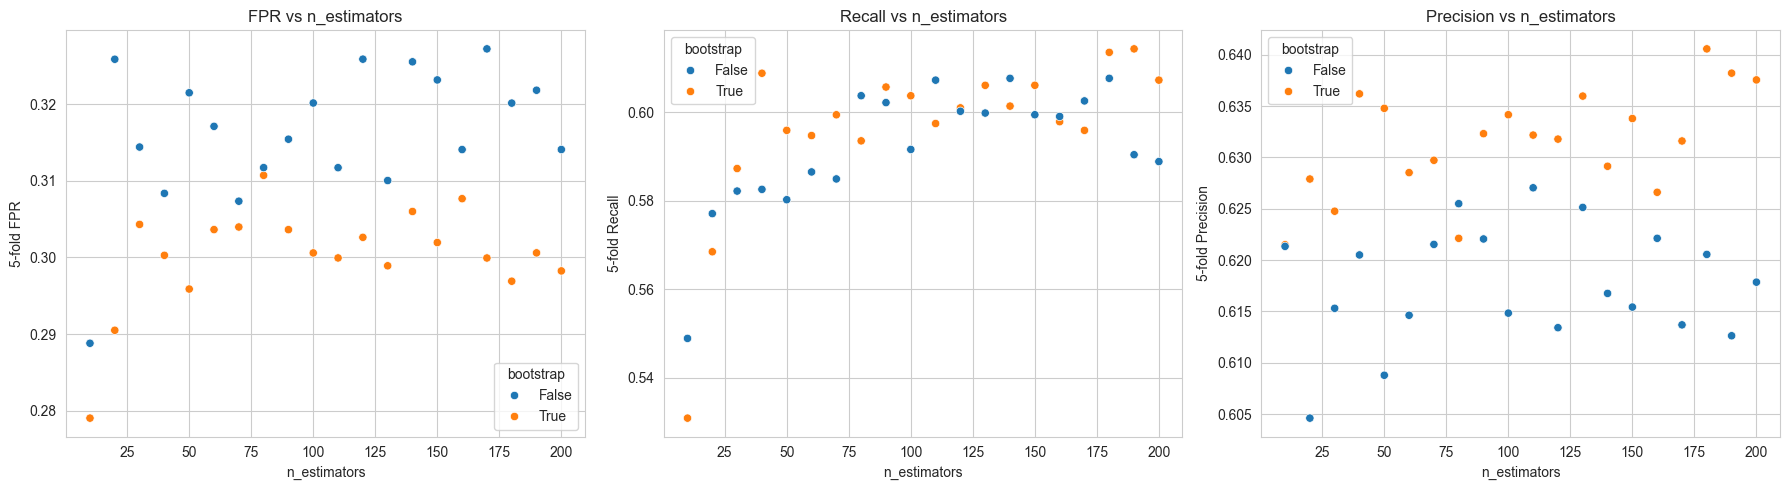

In [156]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_rf_df, x='num_trees', y='fpr_mean', hue='bootstrap', ax=ax[0])
ax[0].set_title('FPR vs n_estimators')
ax[0].set_xlabel('n_estimators')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_rf_df, x='num_trees', y='recall_mean', hue='bootstrap', ax=ax[1])
ax[1].set_title('Recall vs n_estimators')
ax[1].set_xlabel('n_estimators')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_rf_df, x='num_trees', y='precision_mean', hue='bootstrap', ax=ax[2])
ax[2].set_title('Precision vs n_estimators')
ax[2].set_xlabel('n_estimators')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

- FPR - niesłusznie przewidziana recydywa, im niższe tym lepiej.
- Recall - procent osób, które rzeczywiście popełniły recydywę i zostały prawidłowo zidentyfikowane przez model, skuteczność modelu w wykrywaniu zagrożeni, im wyżej tym lepiej (model rzadziej "przeoczy" potencjalnie niebezpieczną osobę).
- Precision - ilu z przewidzianych recydywistów naprawdę nimi jest

Bez bootstrapu - trenujemy na całym zbiorze treningowym.

$$ FPR = \frac{FP}{FP + TN} $$
$$ Recall = \frac{TP}{TP + FN} $$
$$ Precision = \frac{TP}{TP + FP} $$

In [157]:
results_rf_depth = []

for depth in tqdm(range(1, 101), desc="Testing depths"):
    params = {
        'n_estimators': 100,
        'max_depth': depth,
        'min_samples_leaf': 1,
        'bootstrap': True
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=RandomForestClassifier,
        params=params,
        print_results=False
    )
    
    results_rf_depth.append(dict(
        depth=depth,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))

results_rf_depth_df = pd.DataFrame(results_rf_depth)


Testing depths: 100%|██████████| 100/100 [09:20<00:00,  5.61s/it]


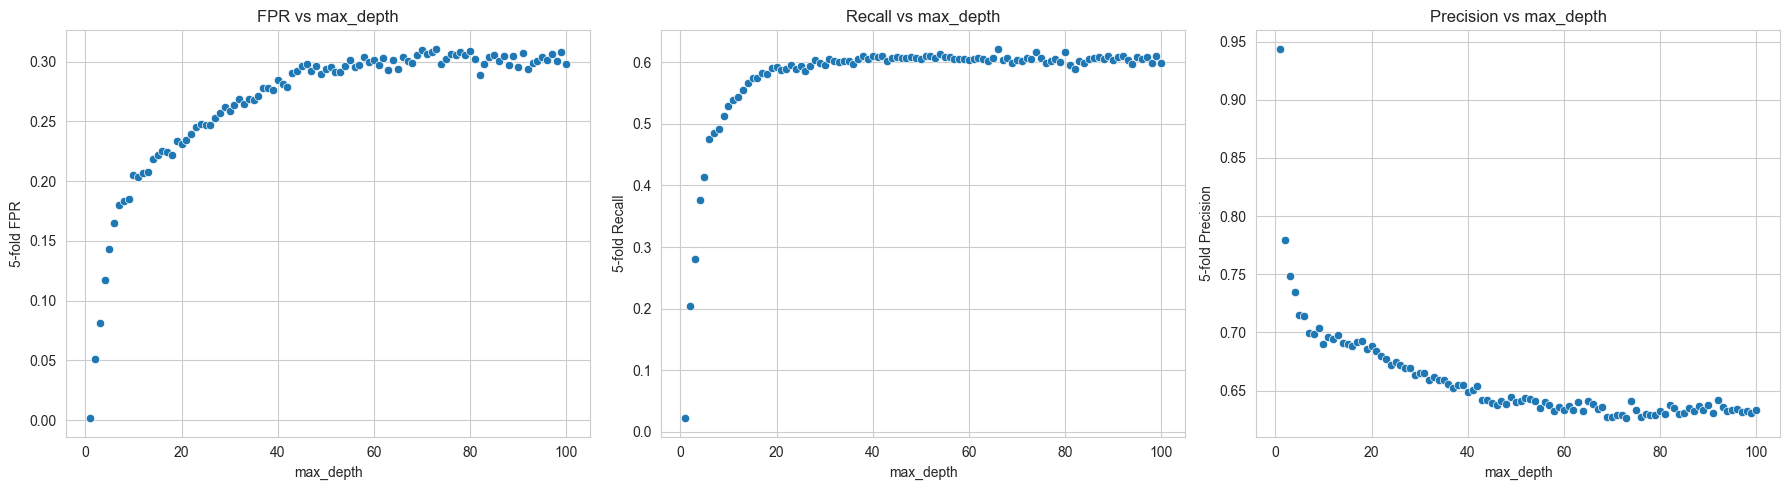

In [158]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_rf_depth_df, x='depth', y='fpr_mean', ax=ax[0])
ax[0].set_title('FPR vs max_depth')
ax[0].set_xlabel('max_depth')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_rf_depth_df, x='depth', y='recall_mean', ax=ax[1])
ax[1].set_title('Recall vs max_depth')
ax[1].set_xlabel('max_depth')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_rf_depth_df, x='depth', y='precision_mean', ax=ax[2])
ax[2].set_title('Precision vs max_depth')
ax[2].set_xlabel('max_depth')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

- FPR przy niskim `max_depth` - model jest zbyt prosty, każdemu przypisujemy nie ma recydywy (klasa większościowa)
- Recall przy niskim `max_depth` - model jest zbyt prosty, wykrywamy nieznaczną część recydywistów
- Precision przy niskim `max_depth` - z nielicznych przypadków, które model oznaczony jako recydywa, większość jest poprawna (bardzo mało FP)

In [159]:
min_samples_leaf = range(1,10)
results_rf_min_samples_leaf = []
for min_samples in tqdm(min_samples_leaf, desc="Testing min_samples_leaf"):
    params = {
        'n_estimators': 100,
        'max_depth': None,
        'min_samples_leaf': min_samples,
        'bootstrap': True
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=RandomForestClassifier,
        params=params,
        print_results=False
    )
    
    results_rf_min_samples_leaf.append(dict(
        min_samples=min_samples,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))
    
results_rf_min_samples_leaf_df = pd.DataFrame(results_rf_min_samples_leaf)

Testing min_samples_leaf: 100%|██████████| 9/9 [00:27<00:00,  3.05s/it]


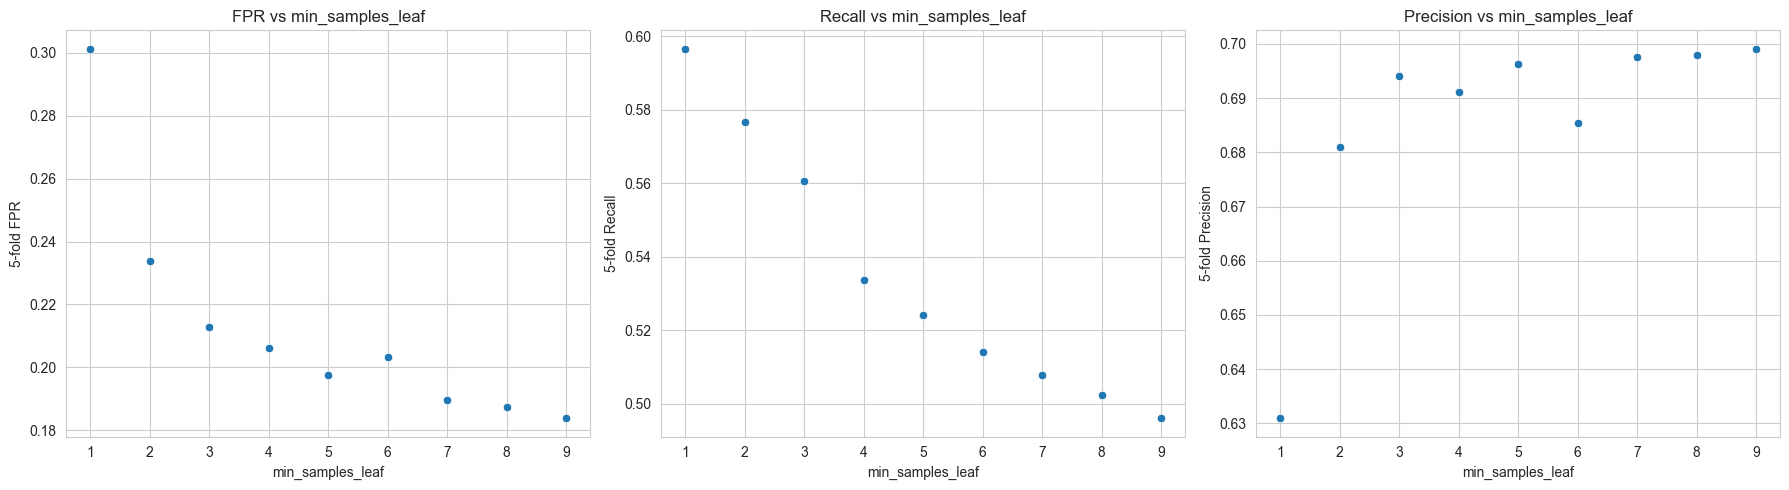

In [160]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_rf_min_samples_leaf_df, x='min_samples', y='fpr_mean', ax=ax[0])
ax[0].set_title('FPR vs min_samples_leaf')
ax[0].set_xlabel('min_samples_leaf')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_rf_min_samples_leaf_df, x='min_samples', y='recall_mean', ax=ax[1])
ax[1].set_title('Recall vs min_samples_leaf')
ax[1].set_xlabel('min_samples_leaf')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_rf_min_samples_leaf_df, x='min_samples', y='precision_mean', ax=ax[2])
ax[2].set_title('Precision vs min_samples_leaf')
ax[2].set_xlabel('min_samples_leaf')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

- Duże min_samples_leaf - niski FPR i wysoka precision, ale niski recall (~0.508–0.496), model przyznaje etykietę $1$ rzadziej, przez co niemal każda taka predykcja jest poprawna, ale wiele prawdziwych recydyw umyka
- Małe min_samples_leaf - wysoki recall, niskie precision, duży FPR - wykrywa wiele recydyw, ale częściej się myli

### AdaBoostClassifier

Niższy `learning_rate` - każda kolejna słaba funkcja ma mniejszy wpływ, więc model uczy się wolniej, potrzebuje więcej drzew (większego `n_estimators`) ale zazwyczaj lepiej uogólnia (mniej *overfittingu*)

Wyższy `learning_rate` - silniejsze dopasowanie w początkowych krokach, szybciej redukuje błąd, ale może przeuczyć się, jeśli `l_rate` jest za duży.

In [161]:
n_estimators = range(10, 201, 10)
learning_rates = [0.1, 0.5, 1.0, 2.0]
results_ada = []
list_of_combinations = list(product(n_estimators, learning_rates))
for n_estimators, learning_rate in tqdm(list_of_combinations, desc="ADA trening"):
    params = {
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'algorithm': 'SAMME'
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=AdaBoostClassifier,
        params=params,
        print_results=False
    )
    
    results_ada.append(dict(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))
    
results_ada_df = pd.DataFrame(results_ada)

ADA trening:   4%|▍         | 3/80 [00:04<01:44,  1.36s/it]c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
ADA trening:   9%|▉         | 7/80 [00:13<02:42,  2.22s/it]c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no pred

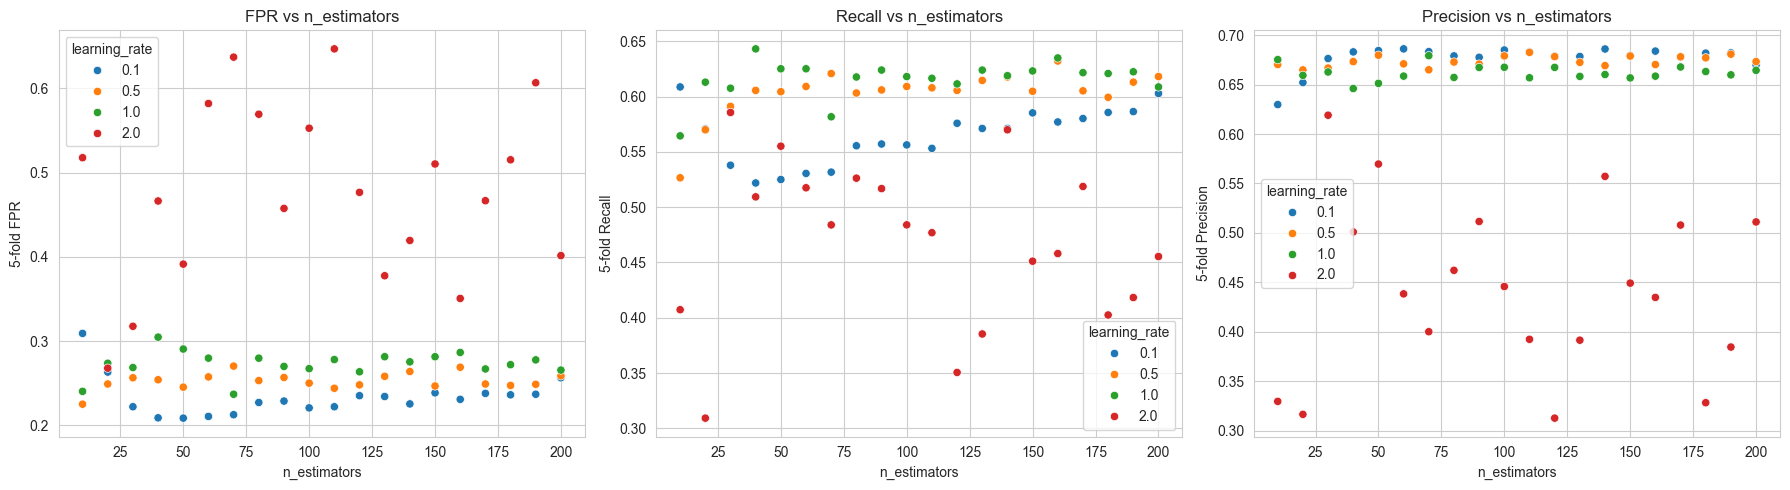

In [162]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_ada_df, x='n_estimators', y='fpr_mean', hue='learning_rate', ax=ax[0], palette='tab10')
ax[0].set_title('FPR vs n_estimators')
ax[0].set_xlabel('n_estimators')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_ada_df, x='n_estimators', y='recall_mean', hue='learning_rate', ax=ax[1], palette='tab10')
ax[1].set_title('Recall vs n_estimators')
ax[1].set_xlabel('n_estimators')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_ada_df, x='n_estimators', y='precision_mean', hue='learning_rate', ax=ax[2], palette='tab10')
ax[2].set_title('Precision vs n_estimators')
ax[2].set_xlabel('n_estimators')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

In [163]:
learning_rates = np.arange(0.1, 2.1, 0.1)
n_estimators = [50, 100, 150]
results_ada_learning_rate = []
list_of_combinations2 = list(product(learning_rates, n_estimators))
for learning_rate, n_estimators in tqdm(list_of_combinations2, desc="ADA learning rate testing"):
    params = {
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'algorithm': 'SAMME'
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=AdaBoostClassifier,
        params=params,
        print_results=False
    )
    
    results_ada_learning_rate.append(dict(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))
results_ada_learning_rate_df = pd.DataFrame(results_ada_learning_rate)

ADA learning rate testing:  95%|█████████▌| 57/60 [11:23<00:40, 13.38s/it]c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
ADA learning rate testing: 100%|██████████| 60/60 [11:59<00:00, 11.99s/it]


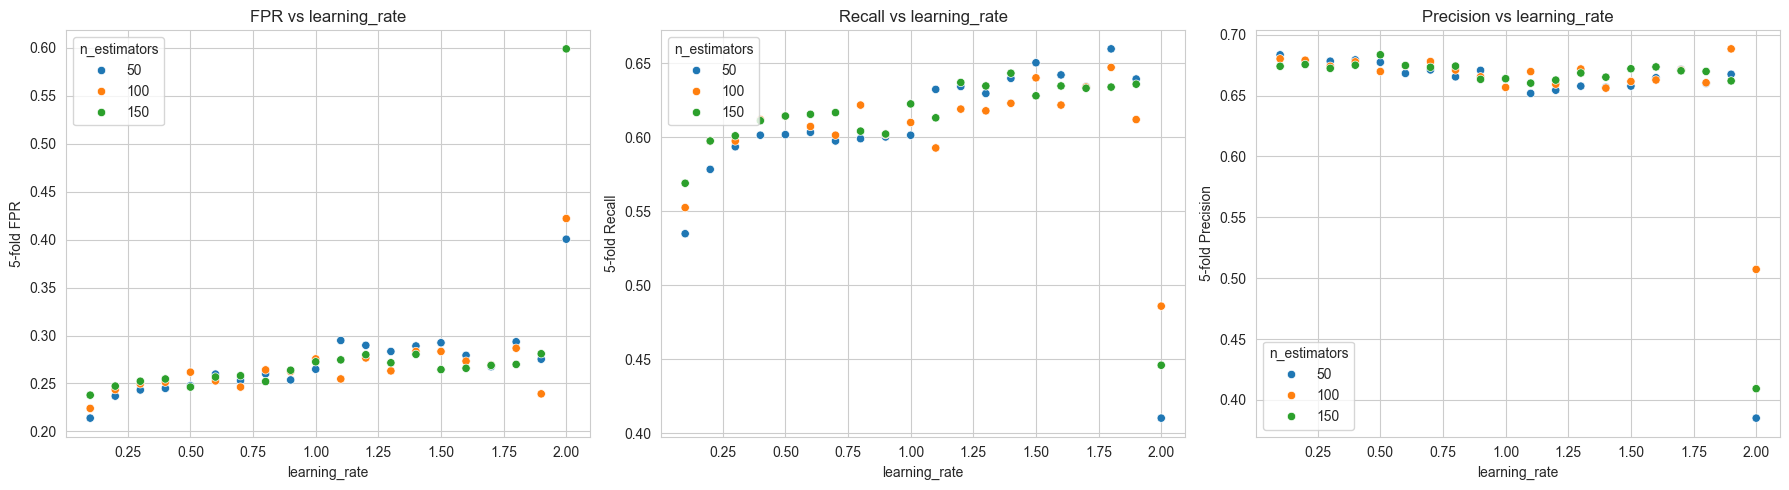

In [164]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_ada_learning_rate_df, x='learning_rate', y='fpr_mean', hue='n_estimators', ax=ax[0], palette='tab10')
ax[0].set_title('FPR vs learning_rate')
ax[0].set_xlabel('learning_rate')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_ada_learning_rate_df, x='learning_rate', y='recall_mean', hue='n_estimators', ax=ax[1], palette='tab10')
ax[1].set_title('Recall vs learning_rate')
ax[1].set_xlabel('learning_rate')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_ada_learning_rate_df, x='learning_rate', y='precision_mean', hue='n_estimators', ax=ax[2], palette='tab10')
ax[2].set_title('Precision vs learning_rate')
ax[2].set_xlabel('learning_rate')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

### HistGradientBoostingClassifier

In [165]:
max_iter = range(10, 500,50)
results_hist = []
for max_iter in tqdm(max_iter, desc="HistGradientBoostingClassifier training"):
    params = {
        'max_iter': max_iter,
        'max_depth': None,
        'min_samples_leaf': 20
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=HistGradientBoostingClassifier,
        params=params,
        print_results=False
    )
    
    results_hist.append(dict(
        max_iter=max_iter,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))
results_hist_df = pd.DataFrame(results_hist)

HistGradientBoostingClassifier training: 100%|██████████| 10/10 [05:15<00:00, 31.56s/it]


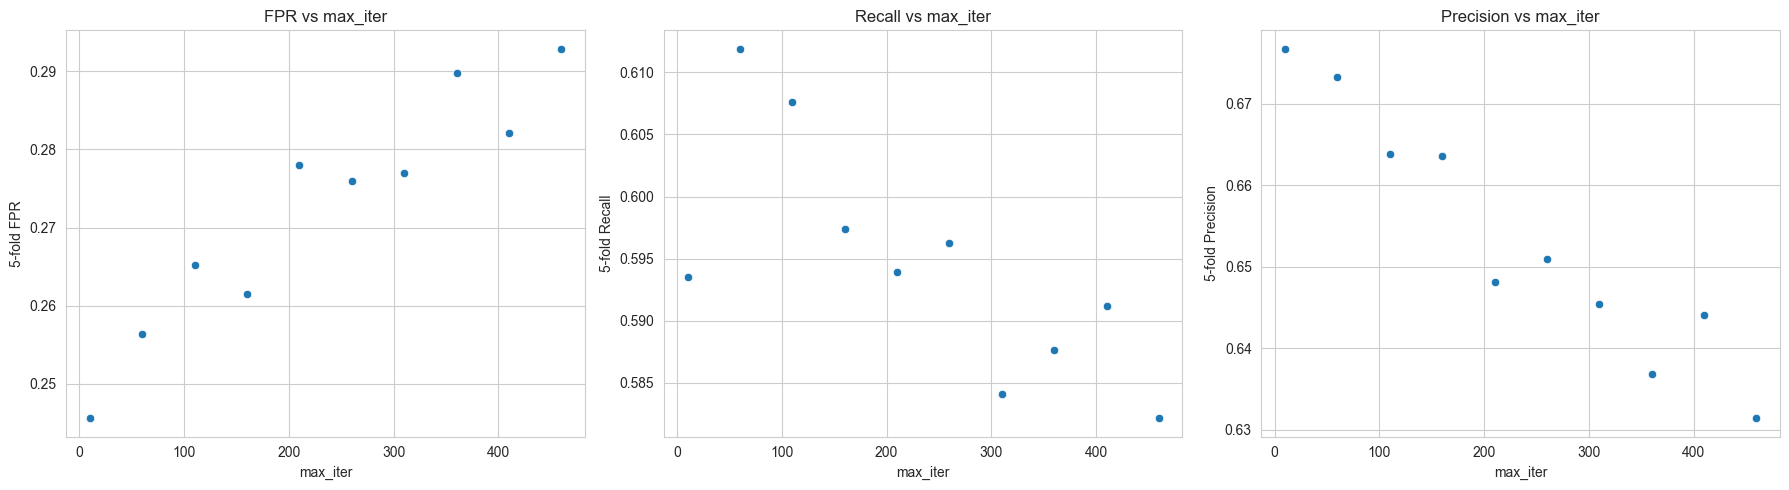

In [166]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_hist_df, x='max_iter', y='fpr_mean', ax=ax[0])
ax[0].set_title('FPR vs max_iter')
ax[0].set_xlabel('max_iter')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_hist_df, x='max_iter', y='recall_mean', ax=ax[1])
ax[1].set_title('Recall vs max_iter')
ax[1].set_xlabel('max_iter')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_hist_df, x='max_iter', y='precision_mean', ax=ax[2])
ax[2].set_title('Precision vs max_iter')
ax[2].set_xlabel('max_iter')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

In [167]:
max_iter = range(50, 80, 1)
results_hist = []
for max_iter in tqdm(max_iter, desc="HistGradientBoostingClassifier max_iter testing"):
    params = {
        'max_iter': max_iter,
        'max_depth': None,
        'min_samples_leaf': 20
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=HistGradientBoostingClassifier,
        params=params,
        print_results=False
    )
    
    results_hist.append(dict(
        max_iter=max_iter,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))
results_hist_df = pd.DataFrame(results_hist)

HistGradientBoostingClassifier max_iter testing: 100%|██████████| 30/30 [05:04<00:00, 10.14s/it]


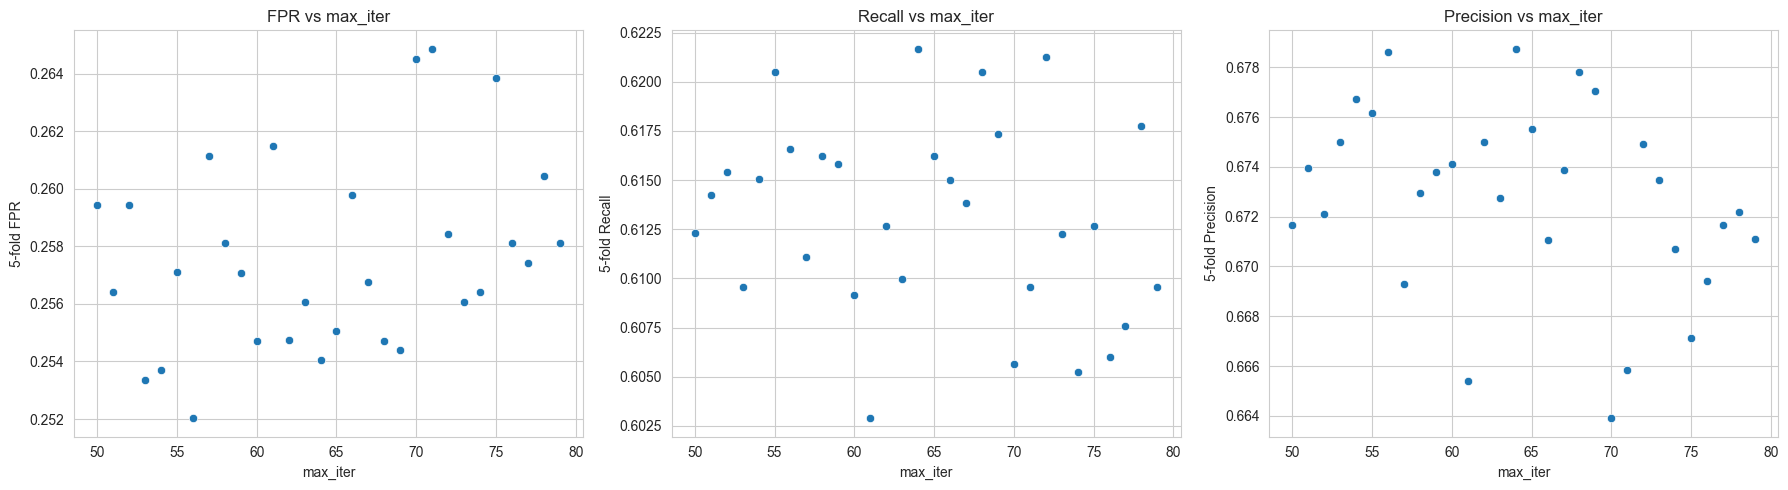

In [168]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_hist_df, x='max_iter', y='fpr_mean', ax=ax[0])
ax[0].set_title('FPR vs max_iter')
ax[0].set_xlabel('max_iter')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_hist_df, x='max_iter', y='recall_mean', ax=ax[1])
ax[1].set_title('Recall vs max_iter')
ax[1].set_xlabel('max_iter')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_hist_df, x='max_iter', y='precision_mean', ax=ax[2])
ax[2].set_title('Precision vs max_iter')
ax[2].set_xlabel('max_iter')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

W HistGradientBoostingClassifier zawsze można ustawić większy `max_iter` i używać `early_stopping` do zatrzymania treningu, gdy nie ma już poprawy.

In [169]:
max_depth = range(1, 100, 10)
results_hist_depth = []
for max_depth in tqdm(max_depth, desc="HistGradientBoostingClassifier max_depth testing"):
    params = {
        'max_iter': 100,
        'max_depth': max_depth,
        'min_samples_leaf': 20
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=HistGradientBoostingClassifier,
        params=params,
        print_results=False
    )
    
    results_hist_depth.append(dict(
        max_depth=max_depth,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))
results_hist_depth_df = pd.DataFrame(results_hist_depth)

HistGradientBoostingClassifier max_depth testing: 100%|██████████| 10/10 [02:12<00:00, 13.29s/it]


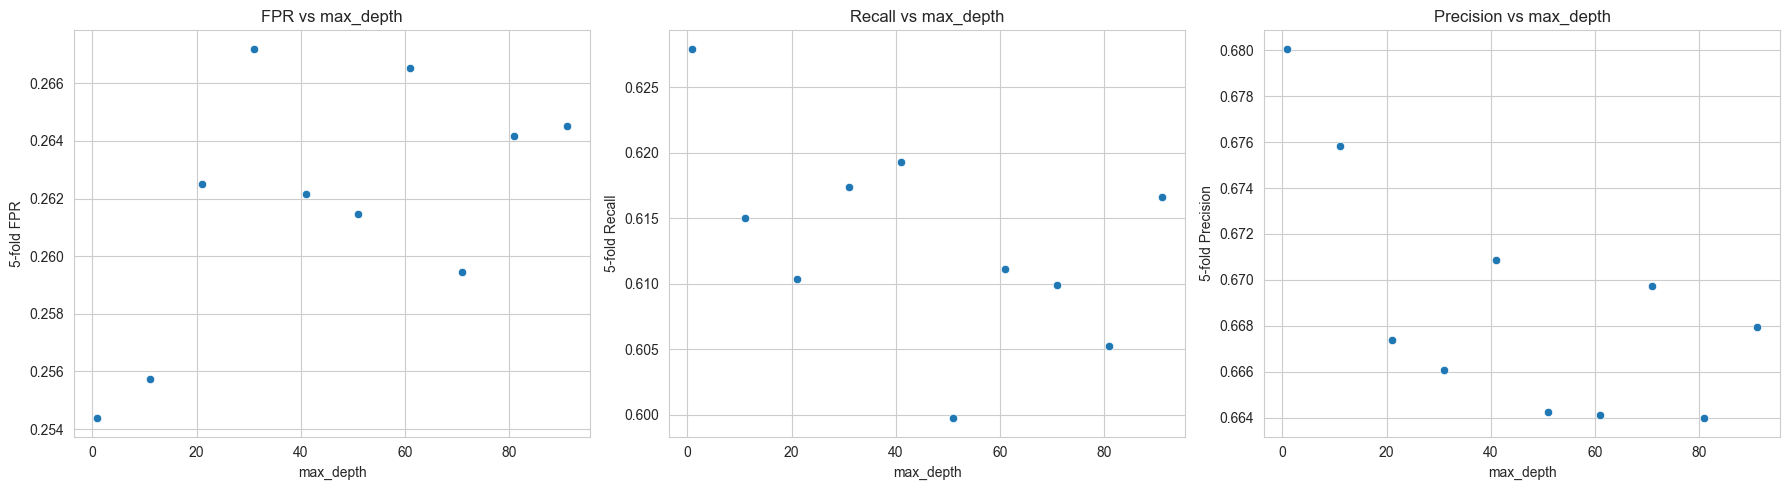

In [170]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_hist_depth_df, x='max_depth', y='fpr_mean', ax=ax[0])
ax[0].set_title('FPR vs max_depth')
ax[0].set_xlabel('max_depth')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_hist_depth_df, x='max_depth', y='recall_mean', ax=ax[1])
ax[1].set_title('Recall vs max_depth')
ax[1].set_xlabel('max_depth')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_hist_depth_df, x='max_depth', y='precision_mean', ax=ax[2])
ax[2].set_title('Precision vs max_depth')
ax[2].set_xlabel('max_depth')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

In [171]:
max_depth = range(1, 15, 1)
results_hist_depth = []
for max_depth in tqdm(max_depth, desc="HistGradientBoostingClassifier max_depth testing"):
    params = {
        'max_iter': 100,
        'max_depth': max_depth,
        'min_samples_leaf': 20
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=HistGradientBoostingClassifier,
        params=params,
        print_results=False
    )
    
    results_hist_depth.append(dict(
        max_depth=max_depth,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))
    
results_hist_depth_df = pd.DataFrame(results_hist_depth)

HistGradientBoostingClassifier max_depth testing: 100%|██████████| 14/14 [02:00<00:00,  8.57s/it]


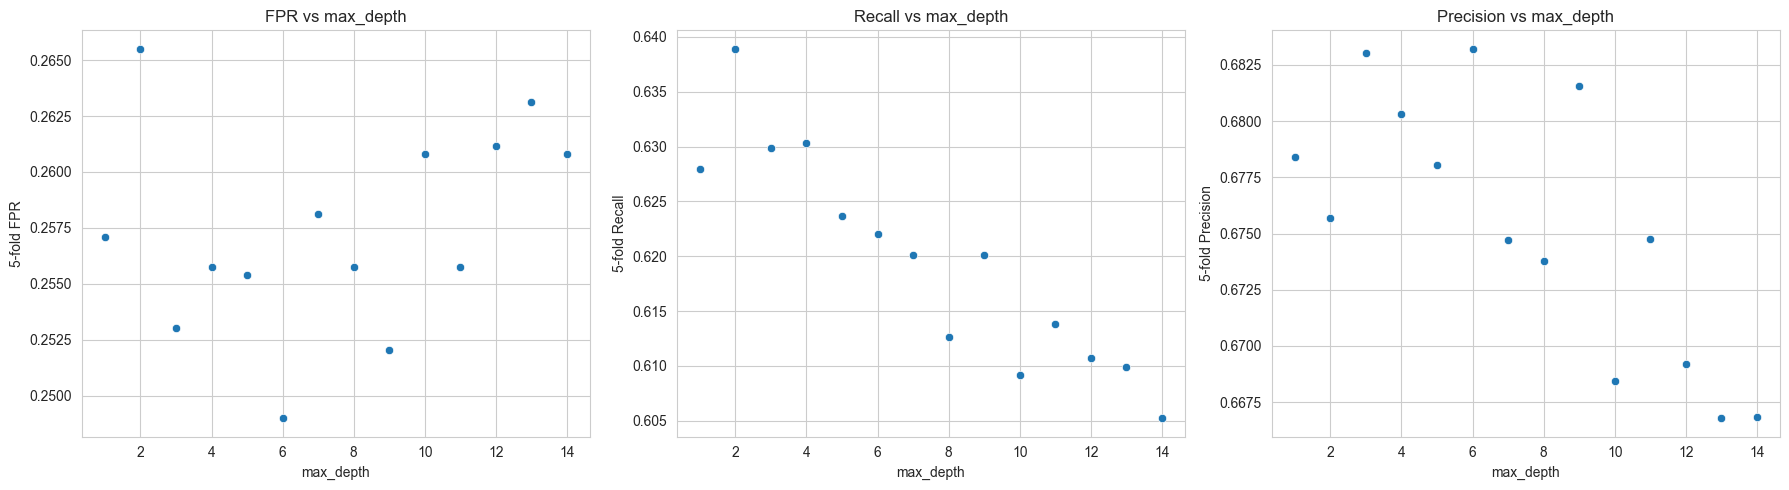

In [172]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_hist_depth_df, x='max_depth', y='fpr_mean', ax=ax[0])
ax[0].set_title('FPR vs max_depth')
ax[0].set_xlabel('max_depth')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_hist_depth_df, x='max_depth', y='recall_mean', ax=ax[1])
ax[1].set_title('Recall vs max_depth')
ax[1].set_xlabel('max_depth')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_hist_depth_df, x='max_depth', y='precision_mean', ax=ax[2])
ax[2].set_title('Precision vs max_depth')
ax[2].set_xlabel('max_depth')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

In [173]:
learning_rates = np.arange(0.01, 0.2, 0.01)
max_iter = [50, 200]
results_hist_learning_rate = []
list_of_combinations3 = list(product(learning_rates, max_iter))
for learning_rate, max_iter in tqdm(list_of_combinations3, desc="HistGradientBoostingClassifier learning rate testing"):
    params = {
        'max_iter': max_iter,
        'max_depth': None,
        'min_samples_leaf': 20,
        'learning_rate': learning_rate
    }
    
    _, fpr_mean, recall_mean, precision_mean = classifier_metrics(
        X_train, y_train, X_test, y_test,
        model=HistGradientBoostingClassifier,
        params=params,
        print_results=False
    )
    
    results_hist_learning_rate.append(dict(
        learning_rate=learning_rate,
        max_iter=max_iter,
        fpr_mean=fpr_mean,
        recall_mean=recall_mean,
        precision_mean=precision_mean
    ))
results_hist_learning_rate_df = pd.DataFrame(results_hist_learning_rate)

HistGradientBoostingClassifier learning rate testing: 100%|██████████| 38/38 [11:37<00:00, 18.35s/it]


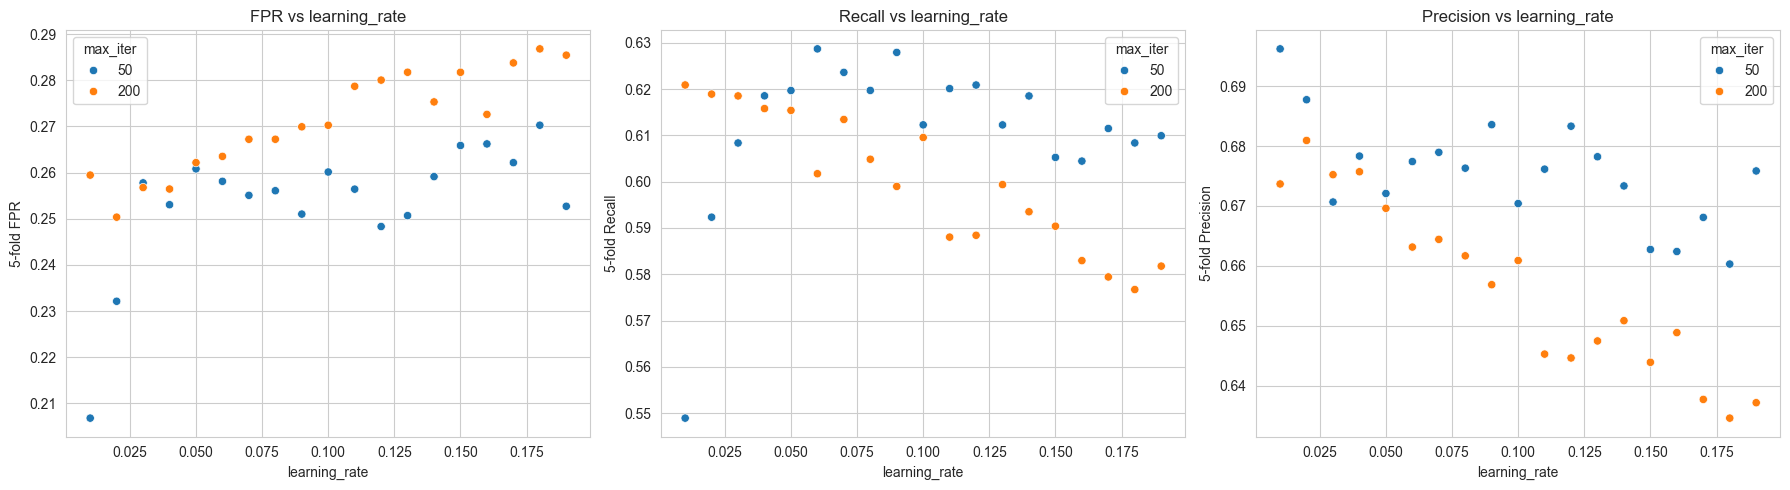

In [174]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=results_hist_learning_rate_df, x='learning_rate', y='fpr_mean', hue='max_iter', ax=ax[0], palette='tab10')
ax[0].set_title('FPR vs learning_rate')
ax[0].set_xlabel('learning_rate')
ax[0].set_ylabel('5-fold FPR')
sns.scatterplot(data=results_hist_learning_rate_df, x='learning_rate', y='recall_mean', hue='max_iter', ax=ax[1], palette='tab10')
ax[1].set_title('Recall vs learning_rate')
ax[1].set_xlabel('learning_rate')
ax[1].set_ylabel('5-fold Recall')
sns.scatterplot(data=results_hist_learning_rate_df, x='learning_rate', y='precision_mean', hue='max_iter', ax=ax[2], palette='tab10')
ax[2].set_title('Precision vs learning_rate')
ax[2].set_xlabel('learning_rate')
ax[2].set_ylabel('5-fold Precision')
plt.tight_layout()
plt.show()

## Szukanie najlepszych hiperparametrów - GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

pipe_rf = build_pipeline(cat_cols, num_cols, RandomForestClassifier())

param_grid_rf = {
    "classifier__n_estimators": [50, 100, 150, 200],
    "classifier__max_depth": [None, 10, 20, 30, 40, 50],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20, 50, 100]
}

rf_grid_search = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=5)

rf_grid_search.fit(X_train, y_train)
print("Najlepsze parametry dla RandomForest:")
print(rf_grid_search.best_params_)
print("Najlepsze średnie F1-macro (CV):")
print(rf_grid_search.best_score_)

pipe_ada = build_pipeline(cat_cols, num_cols, AdaBoostClassifier(algorithm='SAMME'))
param_grid_ada = {
    "classifier__n_estimators": [50, 100, 150, 200],
    "classifier__learning_rate": [0.1, 0.5, 1.0, 2.0]
}
ada_grid_search = GridSearchCV(
    estimator=pipe_ada,
    param_grid=param_grid_ada,
    scoring="f1_macro",
    cv=5)
ada_grid_search.fit(X_train, y_train)
print("Najlepsze parametry dla AdaBoost:")
print(ada_grid_search.best_params_)
print("Najlepsze średnie F1-macro (CV):")
print(ada_grid_search.best_score_)

pipe_hist = build_pipeline(cat_cols, num_cols, HistGradientBoostingClassifier())
param_grid_hist = {
    "classifier__max_iter": [50, 100, 150, 200],
    "classifier__max_depth": [None, 10, 20, 30, 40, 50],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2]
}
hist_grid_search = GridSearchCV(
    estimator=pipe_hist,
    param_grid=param_grid_hist,
    scoring="f1_macro",
    cv=5)
hist_grid_search.fit(X_train, y_train)
print("Najlepsze parametry dla HistGradientBoosting:")
print(hist_grid_search.best_params_)
print("Najlepsze średnie F1-macro (CV):")
print(hist_grid_search.best_score_)

Najlepsze parametry dla RandomForest:
{'classifier__max_depth': 40, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
Najlepsze średnie F1-macro (CV):
0.6737089128251716


c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is 

Najlepsze parametry dla AdaBoost:
{'classifier__learning_rate': 0.5, 'classifier__n_estimators': 100}
Najlepsze średnie F1-macro (CV):
0.6834827621215094
Najlepsze parametry dla HistGradientBoosting:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 20, 'classifier__max_iter': 100}
Najlepsze średnie F1-macro (CV):
0.6828183705355604


## Skuteczność klasyfikatorów

In [60]:
# params for RF: {'classifier__max_depth': 40, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
# params for Ada {'classifier__learning_rate': 0.5, 'classifier__n_estimators': 100}
# params for hist {'classifier__learning_rate': 0.05, 'classifier__max_depth': 20, 'classifier__max_iter': 100}

rf_best_model, fpr_mean_rf, recall_mean_rf, precision_mean_rf = classifier_metrics(
    X_train, y_train, X_test, y_test,
    model=RandomForestClassifier,
    params = {
        'n_estimators': 200,
        'max_depth': 40,
        'min_samples_leaf': 2,
        'bootstrap': True
    },
    print_results=False
)

ada_best_model, fpr_mean_ada, recall_mean_ada, precision_mean_ada = classifier_metrics(
    X_train, y_train, X_test, y_test,
    model=AdaBoostClassifier,
    params = {
        'n_estimators': 100,
        'learning_rate': 0.5,
        'algorithm': 'SAMME'
    },
    print_results=False
)

hist_best_model, fpr_mean_hist, recall_mean_hist, precision_mean_hist = classifier_metrics(
    X_train, y_train, X_test, y_test,
    model=HistGradientBoostingClassifier,
    params = {
        'max_iter': 100,
        'max_depth': 20,
        'min_samples_leaf': 20,
        'learning_rate': 0.05
    },
    print_results=False
)

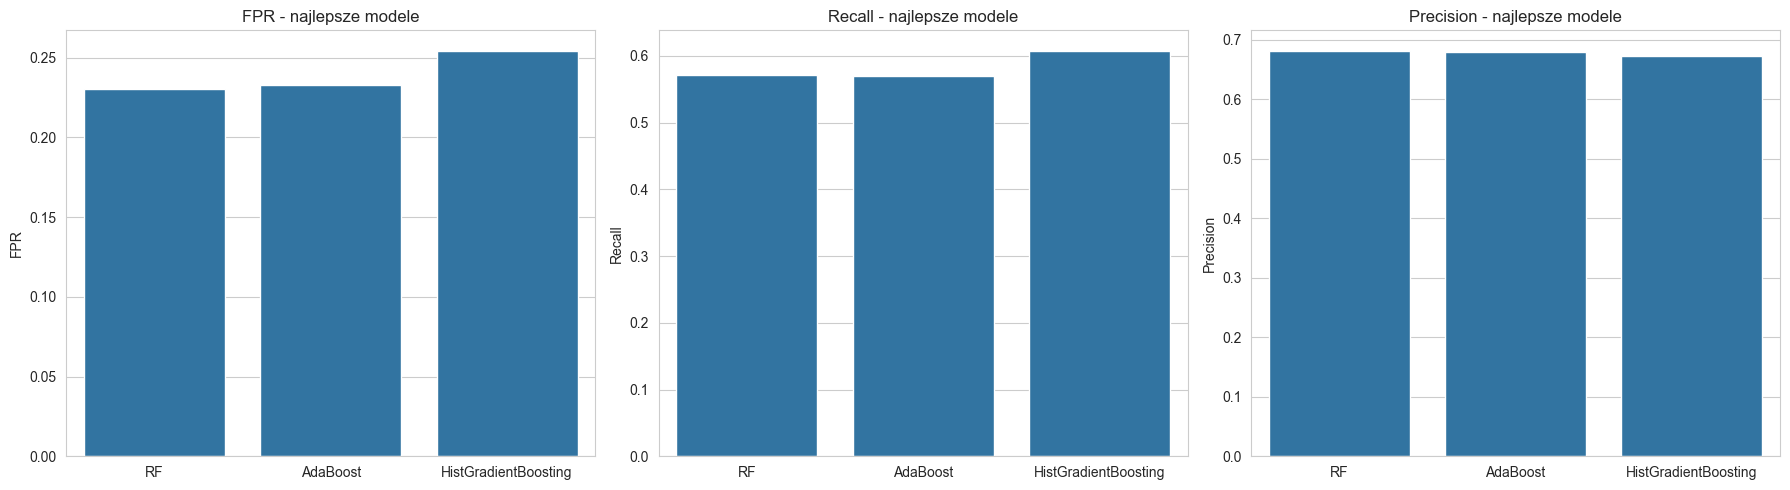

In [61]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x=['RF', 'AdaBoost', 'HistGradientBoosting'], y=[fpr_mean_rf, fpr_mean_ada, fpr_mean_hist], ax=ax[0])
ax[0].set_title('FPR - najlepsze modele')
ax[0].set_ylabel('FPR')
sns.barplot(x=['RF', 'AdaBoost', 'HistGradientBoosting'], y=[recall_mean_rf, recall_mean_ada, recall_mean_hist], ax=ax[1])
ax[1].set_title('Recall - najlepsze modele')
ax[1].set_ylabel('Recall')
sns.barplot(x=['RF', 'AdaBoost', 'HistGradientBoosting'], y=[precision_mean_rf, precision_mean_ada, precision_mean_hist], ax=ax[2])
ax[2].set_title('Precision - najlepsze modele')
ax[2].set_ylabel('Precision')
plt.tight_layout()

- Jeśli chcemy uniknąć fałszywych skazań, to RF lub AdaBoost.
- Jeśli chcemy złapać jak najwięcej potencjalnych recydywistów (Recall), to, HistGradientBoostingClassifier.

## Zrozumiałość klasyfikatorów

In [67]:
def get_feature_names_from_pipeline(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == "cat":
            ohe = transformer
            for i, orig_col in enumerate(cols):
                cat_list = ohe.categories_[i]
                for cat in cat_list:
                    feature_names.append(f"{orig_col}___{cat}")
        elif name == "num":
            feature_names.extend(cols)
    return feature_names
feature_names = get_feature_names_from_pipeline(rf_best_model)
print("Liczba wszystkich cech po preprocessingu:", len(feature_names))
print("Przykładowe nazwy cech (pierwsze 5):", feature_names[:5])

Liczba wszystkich cech po preprocessingu: 386
Przykładowe nazwy cech (pierwsze 5): ['sex___Female', 'sex___Male', 'race___African-American', 'race___Asian', 'race___Caucasian']


### RFC

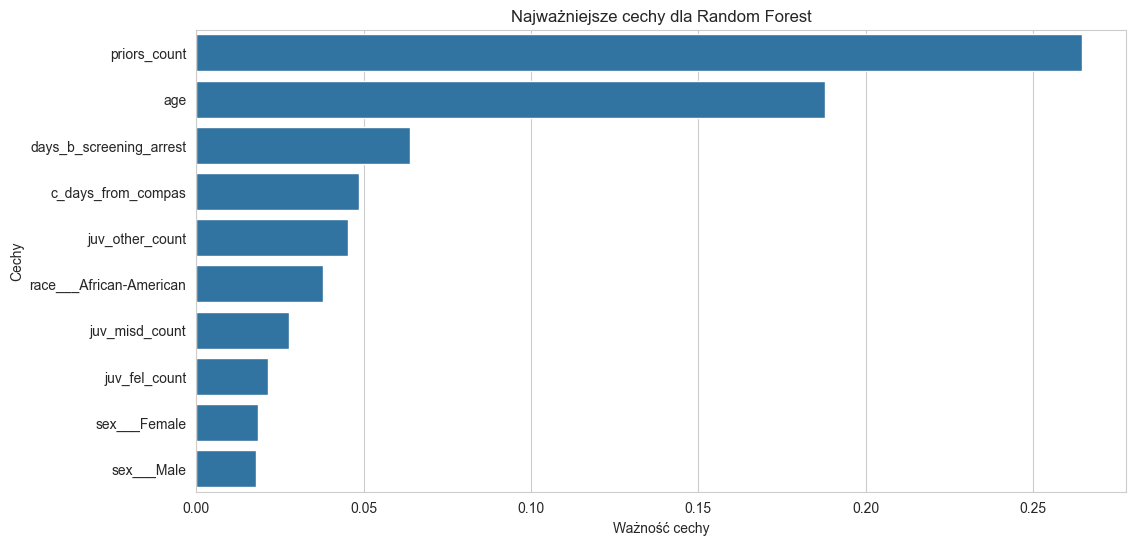

In [ ]:
rf_model = rf_best_model.named_steps['classifier']
importances = rf_model.feature_importances_
df_imp_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=df_imp_rf.head(10))
plt.title('Najważniejsze cechy dla Random Forest')
plt.xlabel('Ważność cechy')
plt.ylabel('Cechy')
plt.show()

`prioris count` - oznacza to, że około $27\%$ wszystkich decyzji w lesie przypadło na podziały właśnie według tej cechy.

### AdaBoost

Jak działa `permutation_importance`:
- Mierzy, jak zmiana wartości cechy wpływa na dokładność modelu.
- Dla każdej cechy, losowo permutuje jej wartości w zbiorze testowym i mierzy spadek dokładności modelu.
- Im większy spadek dokładności, tym ważniejsza jest ta cecha dla modelu.

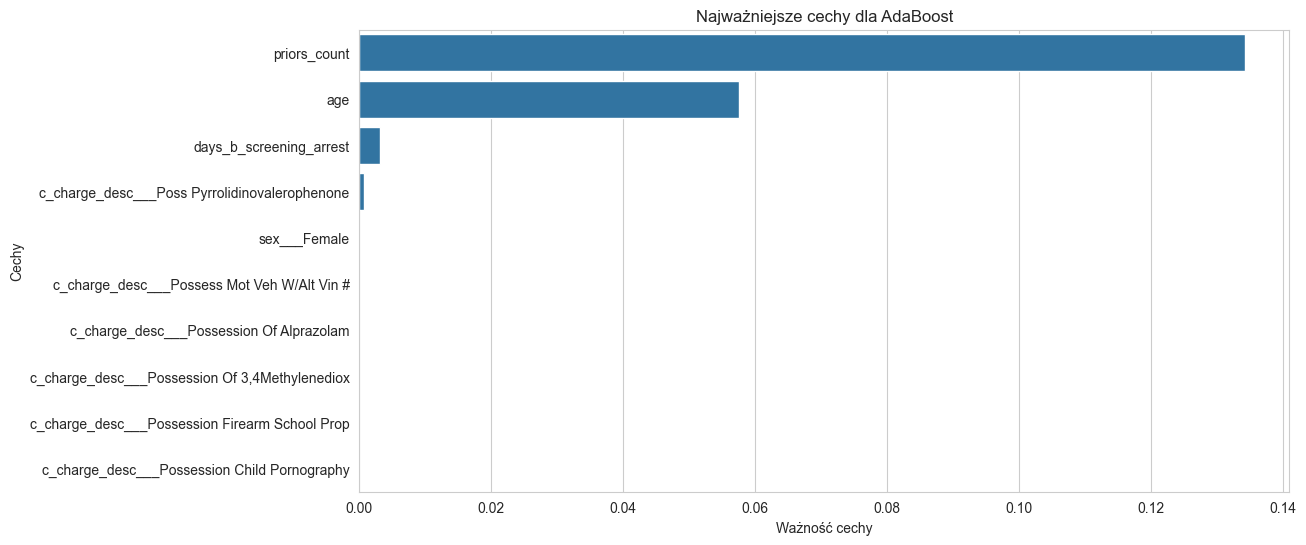

In [175]:
ada_model = ada_best_model.named_steps['classifier']
X_test_transformed = ada_best_model.named_steps['preprocessor'].transform(X_test)
result = permutation_importance(ada_model, X_test_transformed, y_test)
df_imp_ada = pd.DataFrame({
    'feature': feature_names,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=df_imp_ada.head(10))
plt.title('Najważniejsze cechy dla AdaBoost')
plt.xlabel('Ważność cechy')
plt.ylabel('Cechy')
plt.show()

Informuje nas o spadku `accuracy` modelu, gdy wartości danej cechy są losowo mieszane (na wykresie ważność cechy, to o ile by spadła dokładność, gdybyśmy losowo zamienili wartości tej cechy).

### HGB

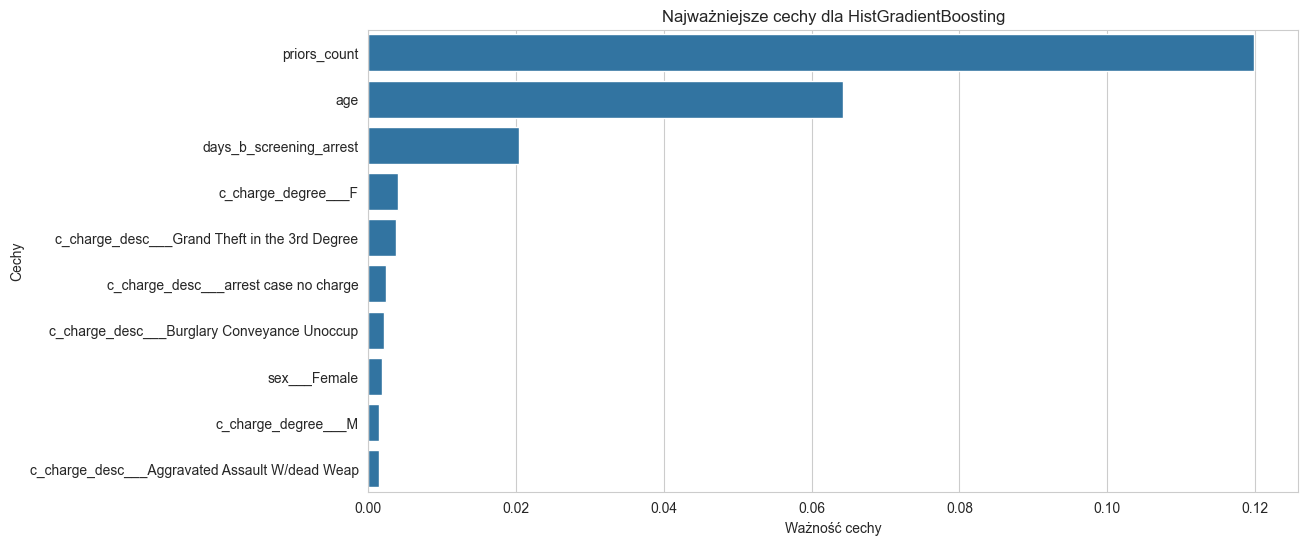

In [69]:
hgb_model = hist_best_model.named_steps['classifier']
X_test_transformed = hist_best_model.named_steps['preprocessor'].transform(X_test)
result = permutation_importance(hgb_model, X_test_transformed, y_test)
df_imp_hist = pd.DataFrame({
    'feature': feature_names,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=df_imp_hist.head(10))
plt.title('Najważniejsze cechy dla HistGradientBoosting')
plt.xlabel('Ważność cechy')
plt.ylabel('Cechy')
plt.show()

## Sprawiedliwość klasyfikatorów

Co robi `MetricFrame`?

- Dzieli dane testowe na podgrupy wg wartości sensitive_features.
- Dla każdej podgrupy liczy zdefiniowane metryki.

In [70]:
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
metrics = {
    'selection_rate': selection_rate,
    'false_positive_rate': false_positive_rate,
    'true_positive_rate (recall)': true_positive_rate,
}

mf_rfc_sex = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=rf_best_model.predict(X_test),
    sensitive_features=X_test['sex'])

mf_rfc_race = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=rf_best_model.predict(X_test),
    sensitive_features=X_test['race'])

mf_ada_sex = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=ada_best_model.predict(X_test),
    sensitive_features=X_test['sex'])

mf_ada_race = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=ada_best_model.predict(X_test),
    sensitive_features=X_test['race'])

mf_hist_sex = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=hist_best_model.predict(X_test),
    sensitive_features=X_test['sex'])

mf_hist_race = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=hist_best_model.predict(X_test),
    sensitive_features=X_test['race'])

In [ ]:
def plot_fairness_metricframes(metricframes: dict, group: str):
    metrics_names = list(next(iter(metricframes.values())).by_group.columns)
    fig, axes = plt.subplots(1, len(metrics_names), figsize=(6 * len(metrics_names), 5))
    if len(metrics_names) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_names):
        df_plot = pd.DataFrame({
            model_name: mf.by_group[metric]
            for model_name, mf in metricframes.items()
        })
        df_plot.plot(kind='bar', ax=ax)
        ax.set_title(f"{metric} by {group}")
        ax.set_ylabel(metric)
        ax.set_xlabel(group)
        ax.legend(title='Model')
    plt.tight_layout()
    plt.show()

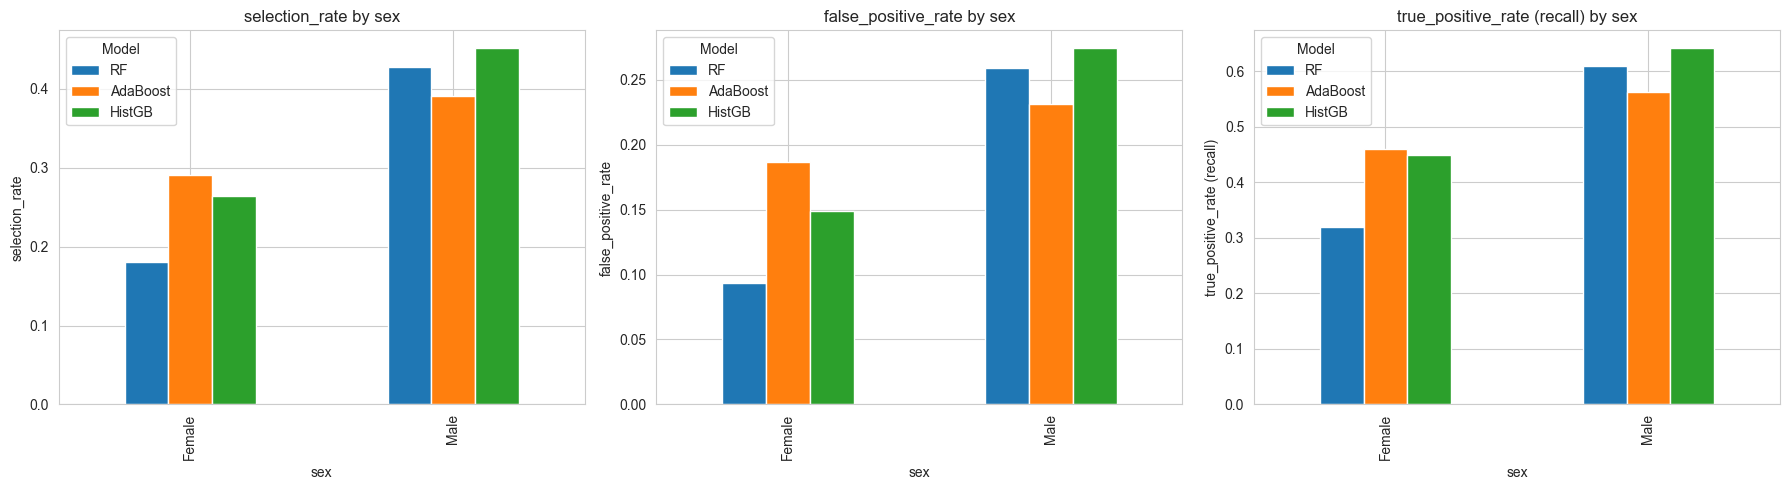

In [ ]:
plot_fairness_metricframes(
    {
        'RF': mf_rfc_sex,
        'AdaBoost': mf_ada_sex,
        'HistGB': mf_hist_sex
    },
    group='sex'
)

1. Modele nie są neutralne płciowo
- Zarówno selection rate, FPR, jak i recall pokazują wyraźne różnice.
- Model RF szczególnie faworyzuje kobiety (niższy FPR), ale niedowartościowuje ich jako potencjalne recydywistki (niższy recall).

Może powinno się zbalansować dane, aby uzyskać bardziej neturalny model.

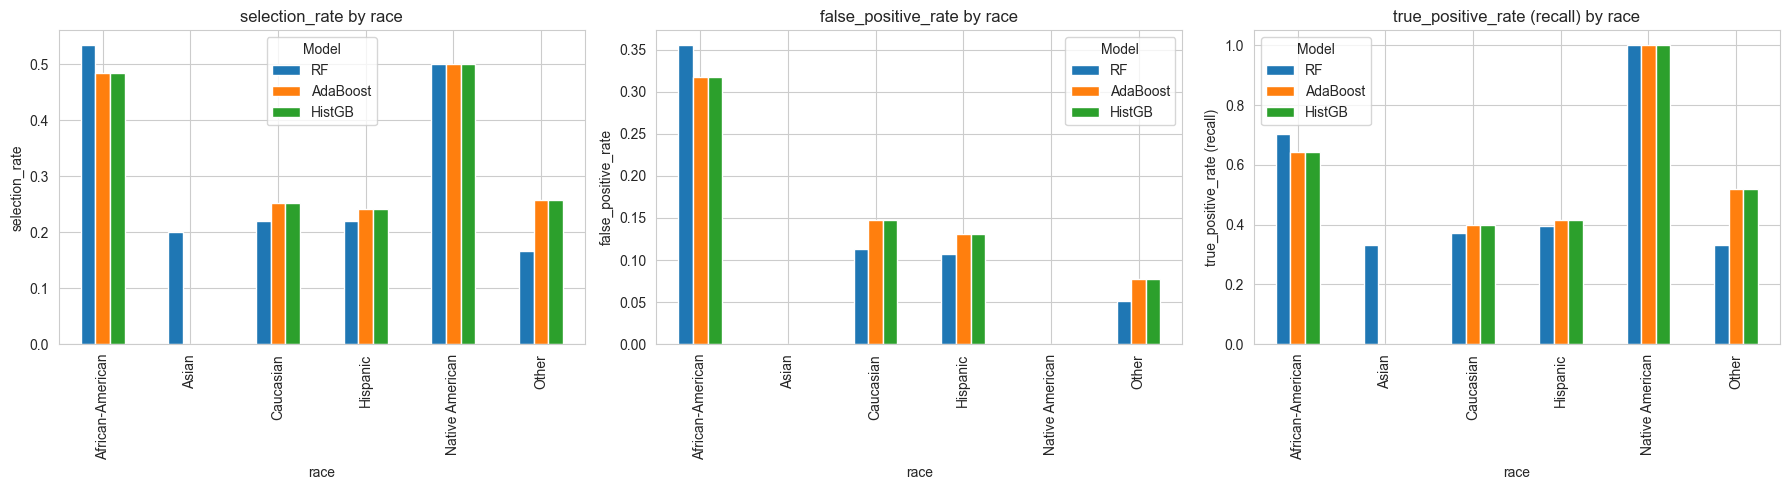

In [75]:
plot_fairness_metricframes(
    {
        'RF': mf_rfc_race,
        'AdaBoost': mf_ada_race,
        'HistGB': mf_ada_race
    },
    group='race'
)

Analiza fairness względem rasy ujawnia, że wszystkie modele znacznie częściej klasyfikują osoby afroamerykańskie jako recydywistów – mają one najwyższy selection rate oraz false positive rate. Modele są wobec tej grupy bardziej "surowe", często niesłusznie przewidując recydywę. Jednocześnie osiągają najwyższy recall właśnie dla Afroamerykanów, co może wskazywać na nadreprezentację tej grupy w danych lub uprzedzenia modelu. W przypadku innych ras (np. Asian, Native American) dane są skąpe, przez co metryki mogą być niestabilne i trudne do interpretacji.

# Eksperyment socjotechniczny

In [97]:
def socjo_exp(X_test, mapping, model, feature_name):
    X_test_copy = X_test.copy()
    X_test_copy[feature_name] = X_test_copy[feature_name].map(mapping)
    y_pred_original = model.predict(X_test)
    y_pred_modified = model.predict(X_test_copy)
    changes = (y_pred_original != y_pred_modified).sum()
    percentage_changes = (changes / len(X_test)) * 100
    print(f"Liczba zmian predykcji dla {feature_name}: {changes}")
    print(f"Procent zmian predykcji dla {feature_name}: {percentage_changes:.2f}%")

In [99]:
print('Dla RFC:')
socjo_exp(X_test, {'African-American': 'Caucasian', 'Caucasian': 'African-American'}, rf_best_model, 'race')
print('Dla AdaBoost:')
socjo_exp(X_test, {'African-American': 'Caucasian', 'Caucasian': 'African-American'}, ada_best_model, 'race')
print('Dla HistGradientBoosting:')
socjo_exp(X_test, {'African-American': 'Caucasian', 'Caucasian': 'African-American'}, hist_best_model, 'race')

Dla RFC:
Liczba zmian predykcji dla race: 149
Procent zmian predykcji dla race: 10.80%
Dla AdaBoost:
Liczba zmian predykcji dla race: 0
Procent zmian predykcji dla race: 0.00%
Dla HistGradientBoosting:
Liczba zmian predykcji dla race: 76
Procent zmian predykcji dla race: 5.51%


In [100]:
print('Dla RFC:')
socjo_exp(X_test, {'Male': 'Female', 'Female':'Male'}, rf_best_model, 'sex')
print('Dla AdaBoost:')
socjo_exp(X_test, {'Male': 'Female', 'Female':'Male'}, ada_best_model, 'sex')
print('Dla HistGradientBoosting:')
socjo_exp(X_test, {'Male': 'Female', 'Female':'Male'}, hist_best_model, 'sex')

Dla RFC:
Liczba zmian predykcji dla sex: 204
Procent zmian predykcji dla sex: 14.78%
Dla AdaBoost:
Liczba zmian predykcji dla sex: 0
Procent zmian predykcji dla sex: 0.00%
Dla HistGradientBoosting:
Liczba zmian predykcji dla sex: 109
Procent zmian predykcji dla sex: 7.90%


In [101]:
X_test.columns

Index(['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'days_b_screening_arrest',
       'c_days_from_compas', 'c_charge_degree', 'c_charge_desc'],
      dtype='object')

# Funkcjonalność zespołu klasyfikatorów

In [152]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ])
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

n_total_features = X_train_transformed.shape[1]
n_onehot = preprocessor.named_transformers_["cat"].transform(X_train[cat_cols]).shape[1]
priors_idx_in_nums = num_cols.index("age")
priors_index = n_onehot + priors_idx_in_nums

hist_baseline = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=20,
    min_samples_leaf=20,
    learning_rate=0.05
)
hist_baseline.fit(X_train_transformed, y_train)
y_pred_hist = hist_baseline.predict(X_test_transformed)

mono_constraint = [0] * n_total_features
mono_constraint[priors_index] = 1

hist_mono = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=20,
    min_samples_leaf=20,
    learning_rate=0.05,
    monotonic_cst=mono_constraint
)
hist_mono.fit(X_train_transformed, y_train)
y_pred_hist_mono = hist_mono.predict(X_test_transformed)

fpr, recall, precision = [], [], []
for model, y_pred in zip(['Baseline', 'Monotonic'], [y_pred_hist, y_pred_hist_mono]):
    fpr.append(false_positive_rate(y_test, y_pred))
    recall.append(true_positive_rate(y_test, y_pred))
    precision.append(precision_score(y_test, y_pred))

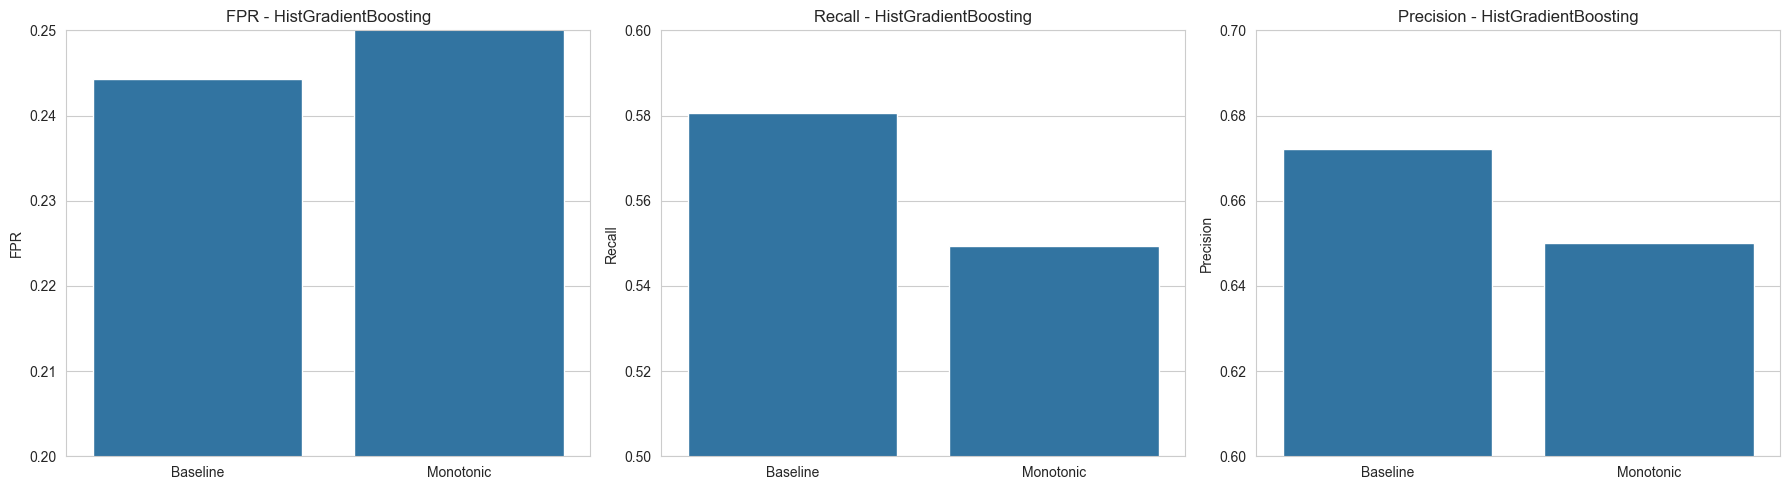

In [154]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x=['Baseline', 'Monotonic'], y=fpr, ax=ax[0])
ax[0].set_title('FPR - HistGradientBoosting')
ax[0].set_ylabel('FPR')
ax[0].set_ylim(0.2, 0.25)
sns.barplot(x=['Baseline', 'Monotonic'], y=recall, ax=ax[1])
ax[1].set_title('Recall - HistGradientBoosting')
ax[1].set_ylabel('Recall')
ax[1].set_ylim(0.5, 0.6)
sns.barplot(x=['Baseline', 'Monotonic'], y=precision, ax=ax[2])
ax[2].set_title('Precision - HistGradientBoosting')
ax[2].set_ylabel('Precision')
ax[2].set_ylim(0.6, 0.7)
plt.tight_layout()
plt.show()

**Bootstrapping** - technika losowania podzbiorów ze zwracaniem z oryginalnego zestawu danych, co pozwala na tworzenie wielu różnych próbek z tego samego zbioru

**Bagging (Bootstrap Aggregating)** - ogólniejsza strategia redukcji wariancji modelu:
- Generujemy kilka bootstrap-sampli.
- Na każdym bootstrap-samplu trenujemy osobny model (np. drzewo decyzyjne).
- Agregujemy ich predykcje (średnia lub głosowanie).

Random Forest to właśnie bagging drzew decyzyjnych z dodatkowym losowym wyborem cech przy podziale. Bagging sprawdza się, gdy bazowy model ma dużą wariancję (łatwo się przeucza), bo uśrednianie wielu modeli stabilizuje prognozy.

Random Forest – bagging drzew:

- trenuje wiele drzew niezależnie na bootstrapped podsampelach
- agreguje przez głosowanie / uśrednianie
- redukuje wariancję, jest odporny na overfitting, ale może być ciężki obliczeniowo

AdaBoost – sekwencyjne wzmacnianie słabych uczniów:
- buduje kolejne „stumpy” (bardzo płytkie drzewa), za każdym razem wagując silniej przykłady błędnie sklasyfikowane
- skoncentrowany na minimalizacji błędów ważonych, wrażliwy na szum, ale prosty do implementacji

HistGradientBoosting – histogram-based gradient boosting:

- przyspiesza budowę drzew przez binning cech do histogramów
- sekwencyjnie dodaje drzewa uczące się na aktualnych residuach (gradientach)
- łączy zalety gradient boosting (wysoka skuteczność) z dużą wydajnością na większych zbiorach